In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import fetch_california_housing

In [3]:
data = fetch_california_housing(as_frame = True)
print(type(data))

<class 'sklearn.utils._bunch.Bunch'>


In [30]:
x = data.data
y = data.target

In [5]:
print(x.head())
print(y.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


In [6]:
print(x.shape, y.shape)
print(x.columns)

(20640, 8) (20640,)
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')


In [7]:
print(type(y))

<class 'pandas.core.series.Series'>


In [8]:
df = x.copy()
df['target'] = y

In [9]:
corrt = df.corr()['target'].sort_values(ascending = False)

In [10]:
corrt

target        1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: target, dtype: float64

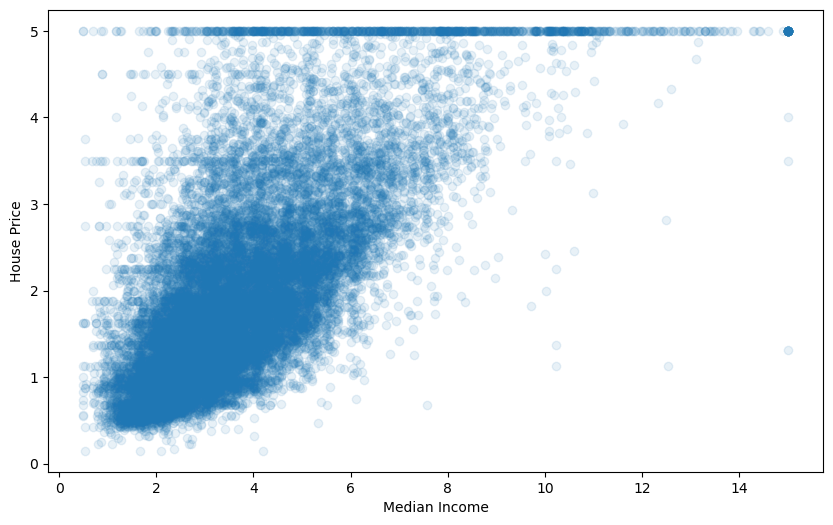

In [11]:
plt.figure(figsize = (10,6))
plt.scatter(x['MedInc'],y,alpha = 0.1)
plt.xlabel('Median Income')
plt.ylabel('House Price')
plt.show()

In [12]:
x.var().sort_values(ascending = False).astype('float64')

Population    1.282470e+06
HouseAge      1.583963e+02
AveOccup      1.078700e+02
AveRooms      6.121533e+00
Latitude      4.562293e+00
Longitude     4.014139e+00
MedInc        3.609323e+00
AveBedrms     2.245915e-01
dtype: float64

In [13]:
corr_matrix = x.corr()

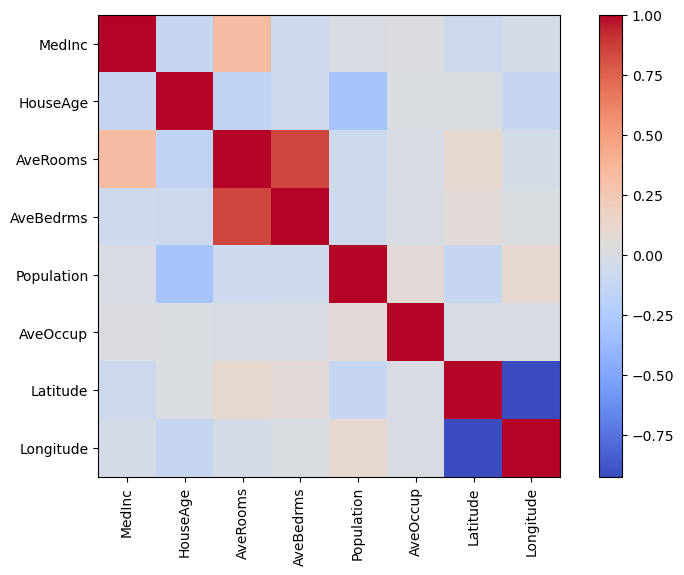

In [14]:
plt.figure(figsize = (10,6))
plt.imshow(corr_matrix, cmap = "coolwarm")
plt.colorbar()
plt.xticks(range(len(x.columns)), x.columns, rotation = 90)
plt.yticks(range(len(x.columns)), x.columns)
plt.show()

In [15]:
class LinearRegression:

    def __init__(self):
        self.w = 0.0
        self.b = 0.0

    def predict_one(self, x):
        y = self.w*x + self.b
        return y

    def predict_many(self,X):
        preds = []
        for x in X:
            preds.append(self.predict_one(x))
        return preds

    def feature_mse(self, X, y_true):
        if len(X) != len(y_true):
            raise ValueError("the lengths of x and y aint the same g wtf check that shit")

        total_error = 0.0
        n = len(y_true)
        for x,yt in zip(X,y_true):
            yp = self.predict_one(x)
            loss = yt - yp
            total_error += loss*loss
        return total_error/n

    def pred_mse(self, y_pred, y_true):
        if len(y_pred) != len(y_true):
            raise ValueError("the lengths of the inputs aint the same g, can't run this shit fr")

        total_error = 0.0
        n = len(y_true)
        for yp,yt in zip(y_pred,y_true):
            loss = yt - yp
            total_error += loss*loss
        return total_error/n

    def compute_gradients(self, X, y_true):
        if len(X) != len(y_true): 
            raise ValueError("lengths dont match my g, for your x and y")

        dw = 0.0
        db = 0.0
        n = len(y_true)

        for x,yt in zip(X,y_true):
            yp = self.predict_one(x)
            err = yt - yp
            dw += -2*err*x
            db += -2*err

        dw /= n
        db /= n

        return dw,db

    def update_params(self, dw,db, lr):
        self.w -= lr*dw
        self.b -= lr*db
        
    def gradient_descent(self, X, y_true, lr = 0.01, n_epochs = 10000, tol = 1e-6):
        losses = []
        for i in range(n_epochs):
            loss = self.feature_mse(X,y_true)
            dw,db = self.compute_gradients(X, y_true)
            self.update_params(dw,db,lr)
            losses.append(loss)

            if i > 0:
                if losses[-1] > losses[-2]:
                    print(f"the loss seems to be increasing at {i}th epoch my g, gonna stop rn and tweak some stuff like lr")
                    break
                elif abs(losses[-2] - losses[-1]) < tol:
                    print(f"the tolerance was achieved at {i}th epoch so gon return that shi rn")
                    break
        print(f"the final loss is {losses[-1]} and parameters are w: {self.w}, b: {self.b}")
        return losses, self.w, self.b

    def normal_equation(self, X,y_true):
        X = np.array(X)
        y = np.array(y_true)

        bias_col = np.ones(len(X), 1)
        X_aug = np.column_stack((X, bias_col))

        theta = np.linalg.inv(X_aug.T @ X_aug) @ X_aug.T @ y

        self.w = theta[0]
        self.b = theta[1]

        return self.w, self.b            

In [16]:
model = LinearRegression()

In [17]:
model.w = 2
model.b = 0
x = [1,2,3,4,5,8,0,7,5]
y = [2,4,5,9,10,5,9,7,0]
model.compute_gradients(x,y)

(41.333333333333336, 4.222222222222222)

In [18]:
print(f"initial loss: {model.feature_mse(x,y)}")
model.gradient_descent(x,y, lr = 0.01, n_epochs = 5000)
print(f"current loss: {model.feature_mse(x,y)}")
print(f"prediction loss: {model.pred_mse(model.predict_many(x), y)}")
print(f"current parameters: {model.w,model.b}")
print(f"normal eqn params : {model.w, model.b}")

initial loss: 39.22222222222222
the tolerance was achieved at 1016th epoch so gon return that shi rn
the final loss is 10.216883101193297 and parameters are w: 0.0324217441322196, b: 5.535732165780756
current loss: 10.216882120146693
prediction loss: 10.216882120146693
current parameters: (0.0324217441322196, 5.535732165780756)
normal eqn params : (0.0324217441322196, 5.535732165780756)


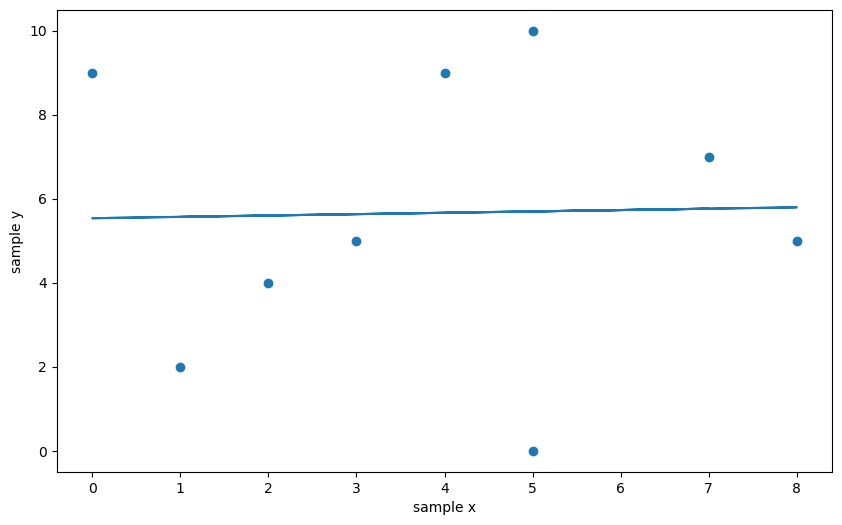

In [19]:
plt.figure(figsize = (10,6))
plt.scatter(x,y)
plt.plot(x,model.predict_many(x))
plt.xlabel('sample x')
plt.ylabel('sample y')
plt.show()

In [20]:
print([i for i in range(10)])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [21]:
class Scaler:

    def __init__(self, method = "normalscaler"):
        if method not in ["normalscaler","minmaxscaler"]:
            raise ValueError('method not recognized by class')
            
        self.method = method
        self.params = {}

    def fit(self, X):
        X = np.array(X)

        if X.ndim == 1:
            X.reshape(-1,1)
            
        if self.method == "normalscaler":
            self.params["mean"] = X.mean(axis=0)
            self.params["std"] = X.std(axis=0) 
            
        elif self.method == "minmaxscaler":
            self.params["min"] = X.min(axis=0)
            self.params["max"] = X.max(axis=0) 

        return self.params

    def transform(self, X):
        X = np.array(X)
        
        if self.method == "normalscaler":
            return (X - self.params["mean"])/(self.params["std"])
            
        elif self.method == "minmaxscaler":
            return (X - self.params["min"])/(self.params["max"] - self.params["min"])

    def fit_transform(self, X):
        X = np.array(X)
        self.fit(X)
        return self.transform(X)

In [22]:
scaler = Scaler(method = "minmaxscaler")

In [23]:
scaler.fit_transform(y)

array([0.2, 0.4, 0.5, 0.9, 1. , 0.5, 0.9, 0.7, 0. ])

In [24]:
len(df.columns)

9

In [25]:
class LinearRegression1:

    '''
    worst code i have written yet
    '''
    def __init__(self):
        self.theta = None

    def _aug(self, X):
        X = np.array(X)
        if X.ndim == 1:
            X = X.reshape(-1,1)
        biascol = np.ones((X.shape[0],1))
        return np.hstack((X,biascol))

    def predict(self, X):
        X = self._aug(X)
        return X@ self.theta

    def mse(self, X, y):
        y_pred = self.predict(X)
        return np.mean((y_pred - y) ** 2)

    def compute_gradients(self, X, y):
        if len(X) != len(y):
            raise ValueError("inputs aren't of the same length")

        
        y_pred = self.predict(X)
        n = len(y)

        error = y_pred - y
        grad = (2 / n) * (X.T @ error)
        return grad

    def gradient_descent(self, X, y, n_epochs=10000, lr=0.01, tol=1e-6):
        if len(X) != len(y):
            raise ValueError("inputs aren't of the same length")

        if self.theta is None:
            self.theta = np.zeros(X.shape[1] + 1)

        losses = []

        for i in range(n_epochs):
            grad = self.compute_gradients(X, y)
            self.theta -= lr * grad

            loss = self.mse(X, y)
            losses.append(loss)

            if i > 1:
                if losses[-1] > losses[-2]:
                    print(f"loss increasing at epoch {i}")
                    break
                elif abs(losses[-2] - losses[-1]) < tol:
                    print(f"converged at epoch {i}")
                    break

        return self.theta

    def normal_equation(self, X, y):
        Xaug = self._aug(X)
        self.theta = np.linalg.inv(Xaug.T @ Xaug) @ Xaug.T @ y
        return self.theta


In [26]:
model1 = LinearRegression1()

In [40]:
class LinearRegression2: #final class for linear regression that works the most

    def __init__(self):
        self.theta = None

    def _aug(self,X):
        if X.ndim == 1:
            X = X.reshape(-1,1)

        biascol = np.ones((X.shape[0],1))
        X = np.hstack((biascol, X))
        return X

    def fit(self, X,y, lr = 0.01, n_epoch = 10000, tol = 1e-6, penalty = "None", reg=0):
        X = self._aug(X)
        if y.ndim == 1:
            y = np.reshape(y, (len(y),1))
        n,d_1 = X.shape

        if self.theta is None:
            self.theta = np.ones((d_1,1))

        losses = []

        for i in range(n_epoch):
            y_pred = X @ self.theta
            assert y_pred.shape == y.shape, f"the shapes of {y_pred} and {y} are not the same"   
            err = y_pred - y
            
            mse = np.mean(err*err)
            grad = (2/n)*(X.T @ err)
            if penalty == "l2":
                grad[1:] += 2*reg*self.theta[1:]    
            elif penalty == "l1": 
                grad[1:] += reg*np.sign(self.theta[1:])
            self.theta -= lr*grad
            losses.append(mse)
            if i>0:
                if losses[-1] > losses[-2]:
                    print(f"the losses started to increase at epoch: {i}")
                    break
                elif abs(losses[-2] - losses[-1]) < tol:
                    print(f"the losses converge to below tolerance at epoch: {i}")
                    break
        print(f"the loss at the final epoch was {losses[-1]} and the theta values are {self.theta}")
        return self.theta

    def predict(self, X):
        if self.theta is None:
            raise ValueError("model not fit yet")
        X = self._aug(X)
        pred = X @ self.theta
        return pred       

In [28]:
print(np.ones((19,1)).shape)

(19, 1)


In [31]:
biascol = np.ones((x.shape[0],1))
xa = np.hstack((x,biascol))
print(xa.shape)
print(x.shape)
theta = np.zeros((xa.shape[1],1))
print(theta.shape)
pred = xa @ theta
print(pred.shape)
print(y.shape)
y = np.reshape(y,(len(y),1))
err = pred - y
print(err.shape)

(20640, 9)
(20640, 8)
(9, 1)
(20640, 1)
(20640,)
(20640, 1)


In [32]:
model = LinearRegression2()
model.fit(x,y)

the losses started to increase at epoch: 1
the loss at the final epoch was 1.4082874753717168e+16 and the theta values are [[ 7.22018903e+06]
 [ 4.78376604e+07]
 [ 9.84510377e+06]
 [ 1.99569195e+06]
 [ 4.32085639e+09]
 [ 6.78542559e+06]
 [ 6.60003624e+07]
 [-2.22329804e+08]
 [ 1.86187443e+06]]


array([[ 7.22018903e+06],
       [ 4.78376604e+07],
       [ 9.84510377e+06],
       [ 1.99569195e+06],
       [ 4.32085639e+09],
       [ 6.78542559e+06],
       [ 6.60003624e+07],
       [-2.22329804e+08],
       [ 1.86187443e+06]])

In [33]:
x

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [34]:
scaler = Scaler(method = "normalscaler")

In [35]:
x = scaler.fit_transform(x)

In [36]:
x

array([[ 2.34476576,  0.98214266,  0.62855945, ..., -0.04959654,
         1.05254828, -1.32783522],
       [ 2.33223796, -0.60701891,  0.32704136, ..., -0.09251223,
         1.04318455, -1.32284391],
       [ 1.7826994 ,  1.85618152,  1.15562047, ..., -0.02584253,
         1.03850269, -1.33282653],
       ...,
       [-1.14259331, -0.92485123, -0.09031802, ..., -0.0717345 ,
         1.77823747, -0.8237132 ],
       [-1.05458292, -0.84539315, -0.04021111, ..., -0.09122515,
         1.77823747, -0.87362627],
       [-0.78012947, -1.00430931, -0.07044252, ..., -0.04368215,
         1.75014627, -0.83369581]])

In [37]:
model.fit(x,y)

the loss at the final epoch was 299187.88872492936 and the theta values are [[ -620.21995249]
 [ -114.21193459]
 [ 1177.06029355]
 [ -974.97755732]
 [  -33.53493745]
 [   22.87419665]
 [-1417.52759738]
 [-1345.02434108]
 [    2.06855817]]


array([[ -620.21995249],
       [ -114.21193459],
       [ 1177.06029355],
       [ -974.97755732],
       [  -33.53493745],
       [   22.87419665],
       [-1417.52759738],
       [-1345.02434108],
       [    2.06855817]])

In [38]:
model.predict(x,y)

array([[-349.11441193],
       [-463.89936171],
       [ 439.94104726],
       ...,
       [-740.16529861],
       [-776.90890707],
       [-976.62944306]])